# MDR-TS v1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Playing around with feature sets

## 0. Imports

In [43]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

import torch

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v1"
SUBVERSION = "v1"
RUN_NAME = "mdr_ts_v1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v1/v1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [6]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_ema_G_API_kobs7',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
    ]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 38
  Target:   soil_moisture_5cm


In [7]:
corr = train_df[FEATURE_COLS].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# find pairs > 0.995 correlation
high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.995
]

print("Highly correlated pairs:")
for a, b, c in high_corr:
    print(f"{a} <-> {b} : {c:.5f}")

Highly correlated pairs:
V_rollmean_G_API_kobs7 <-> V_ema_G_API_kobs7 : 0.99727


In [8]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics):
    print(f"{'METRIC':<15} | {'VALUE':<10}")
    print("-" * 28)
    for k, v in metrics.items():
        val_str = f"{v:,}" if isinstance(v, int) else f"{v:+.5f}"
        print(f"{k:<15} | {val_str:<10}")

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [10]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

trainval_df_d["date"] = pd.to_datetime(trainval_df_d["date"], errors="coerce")
trainval_df_d["year"] = trainval_df_d["date"].dt.year.astype(float)

max_year = trainval_df_d["year"].max()
beta = 0.2

w_trainval = np.exp(beta * (trainval_df_d["year"] - max_year))
w_trainval = w_trainval / w_trainval.mean()

In [11]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval_d = trainval_df_d[FEATURE_COLS].copy()
y_trainval_d = trainval_df_d[TARGET_COL].copy()

X_test_d = test_df[FEATURE_COLS].copy()
y_test_d = test_df[TARGET_COL].copy()

print("\nDRIFT matrices:")
print("  X_trainval_d:", X_trainval_d.shape)
print("  X_test_d:    ", X_test_d.shape)


DRIFT matrices:
  X_trainval_d: (9588, 38)
  X_test_d:     (4016, 38)


### Drift Model (With Weights)

In [37]:
# RF_PARAMS = dict(
#     random_state=SEED,
#     n_estimators=1000,
#     max_depth=20,
#     min_samples_split=4,
#     min_samples_leaf=2,
#     max_features="sqrt",
#     n_jobs=-1,
# )

RF_PARAMS = dict(
    n_estimators=1000,
    max_depth=28,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=-1,
)


In [38]:
w_trainval_s = pd.Series(w_trainval)
years_tv = trainval_df_d["year"].reset_index(drop=True)

print("Weight stats:")
print(w_trainval_s.describe())

min_year = years_tv.min()
max_year = years_tv.max()

print("Min year weight:", float(w_trainval_s[years_tv == min_year].mean()))
print("Max year weight:", float(w_trainval_s[years_tv == max_year].mean()))

Weight stats:
count    9588.000000
mean        1.000000
std         0.336108
min         0.591030
25%         0.721885
50%         0.881713
75%         1.315361
max         1.606585
Name: year, dtype: float64
Min year weight: 0.5910295759572686
Max year weight: 1.6065849564064987


In [39]:
rf_drift_w_tv = RandomForestRegressor(**RF_PARAMS)
rf_drift_w_tv.fit(
    trainval_df_d[FEATURE_COLS],
    trainval_df_d[TARGET_COL],
    sample_weight=w_trainval
)

y_test_d_w = np.asarray(test_df[TARGET_COL]).ravel()
pred_drift_test_w = np.asarray(rf_drift_w_tv.predict(test_df[FEATURE_COLS])).ravel()

In [40]:
metrics_dashboard(y_test_d_w, pred_drift_test_w, name="Test w Weights", return_dict=False)

In [41]:
print("======= MODEL METRICS =======")
neat_print(get_metrics_dict(y_test_d, pred_drift_test_w, prefix="no_w_"))

======= MODEL METRICS =======
METRIC          | VALUE     
----------------------------
no_w_n          | 4,016     
no_w_r2         | +0.83055  
no_w_mae        | +0.02827  
no_w_rmse       | +0.03876  
no_w_ubrmse     | +0.03875  
no_w_bias       | -0.00092  
no_w_med_ae     | +0.02168  
no_w_p90_ae     | +0.05938  
no_w_q05_err    | -0.06284  
no_w_q50_err    | -0.00087  
no_w_q95_err    | +0.05647  


In [ ]:
perm_importance = permutation_importance(
    rf_drift_w_tv,
    trainval_df_d[FEATURE_COLS],
    trainval_df_d[TARGET_COL],
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

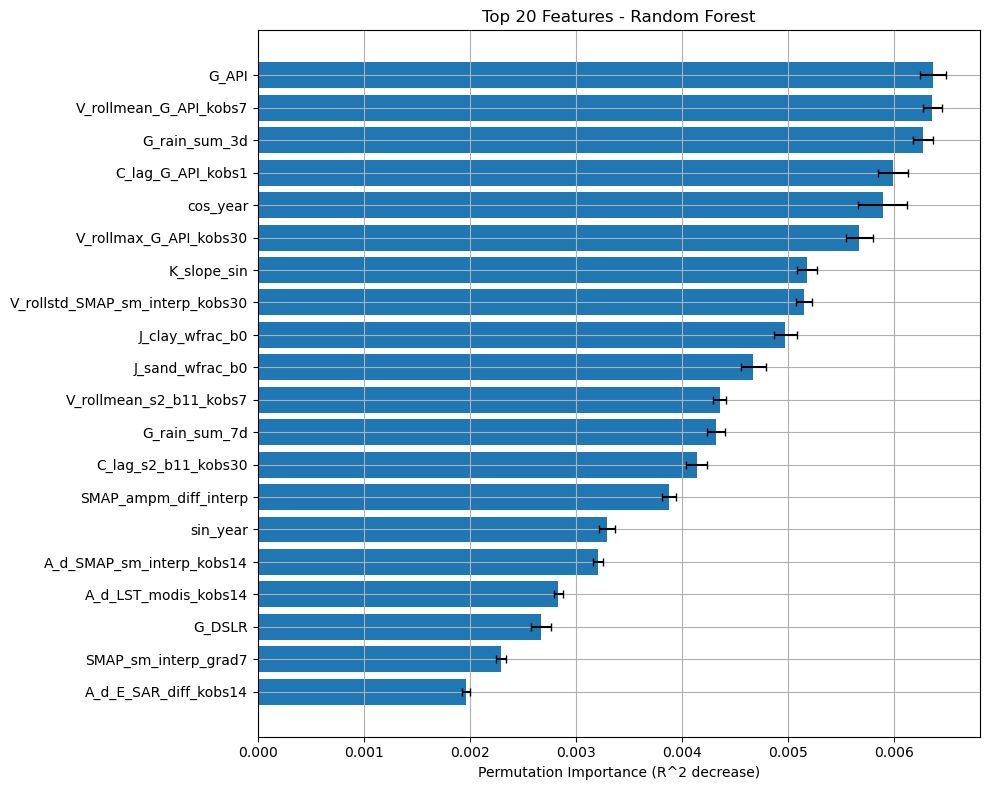

In [ ]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['feature'][:20], importance_df['importance'][:20],
        xerr=importance_df['std'][:20], capsize=3)
ax.set_xlabel('Permutation Importance (R^2 decrease)')
ax.set_title('Top 20 Features - Random Forest')
plt.tight_layout()
plt.show()

In [46]:
print(importance_df.head(20))

                            feature  importance       std
20            A_d_E_SAR_diff_kobs14    0.001964  0.000039
25             SMAP_sm_interp_grad7    0.002295  0.000046
12                           G_DSLR    0.002675  0.000094
22             A_d_LST_modis_kobs14    0.002834  0.000041
23        A_d_SMAP_sm_interp_kobs14    0.003205  0.000048
27                         sin_year    0.003292  0.000076
13            SMAP_ampm_diff_interp    0.003880  0.000064
19              C_lag_s2_b11_kobs30    0.004137  0.000098
6                     G_rain_sum_7d    0.004322  0.000082
16          V_rollmean_s2_b11_kobs7    0.004354  0.000064
37                  J_sand_wfrac_b0    0.004673  0.000116
36                  J_clay_wfrac_b0    0.004973  0.000109
24  V_rollstd_SMAP_sm_interp_kobs30    0.005152  0.000079
33                      K_slope_sin    0.005180  0.000095
14           V_rollmax_G_API_kobs30    0.005673  0.000128
28                         cos_year    0.005893  0.000234
8             

### Residuals

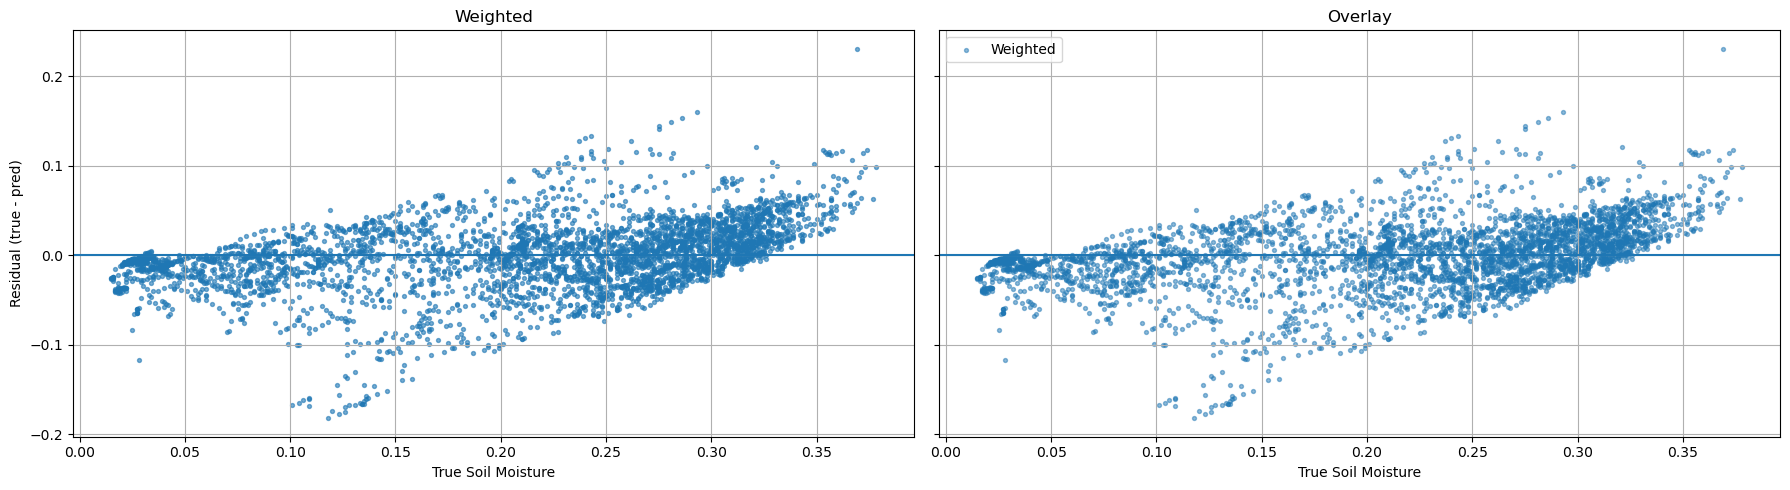

In [47]:
res_w   = y_test_d - pred_drift_test_w

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

axes[0].scatter(y_test_d, res_w, s=8, alpha=0.6)
axes[0].axhline(0)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title("Weighted")

axes[1].scatter(y_test_d, res_w,  s=8, alpha=0.5, label="Weighted")
axes[1].axhline(0)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_title("Overlay")
axes[1].legend()

plt.tight_layout()
plt.show()

### Spatial Evaluation

In [50]:
loso_results = []

stations = trainval_df_d['station_id'].unique()

for held_out_station in stations:
    train_mask = trainval_df_d['station_id'] != held_out_station
    test_mask = trainval_df_d['station_id'] == held_out_station

    X_train = trainval_df_d.loc[train_mask, FEATURE_COLS]
    y_train = trainval_df_d.loc[train_mask, TARGET_COL]
    X_test = trainval_df_d.loc[test_mask, FEATURE_COLS]
    y_test = trainval_df_d.loc[test_mask, TARGET_COL]

    rf_loso = RandomForestRegressor(**RF_PARAMS)
    rf_loso.fit(X_train, y_train)

    y_pred = rf_loso.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    _rmse = rmse(y_test, y_pred)

    loso_results.append({
        'station': held_out_station,
        'n': len(y_test),
        'r2': r2,
        'mae': mae,
        'rmse': _rmse,
    })

loso_df = pd.DataFrame(loso_results)
print(loso_df.to_string(index=False))

              station    n        r2      mae     rmse
           Darrington 2048  0.682223 0.051529 0.061302
SourdoughGulch_WA_985 2190  0.552853 0.055824 0.067866
             Quinault 2160  0.159831 0.057591 0.067576
       Touchet_WA_824 1397 -0.064294 0.082194 0.093872
              Spokane 1793  0.791847 0.041853 0.049420


## Diagnostics

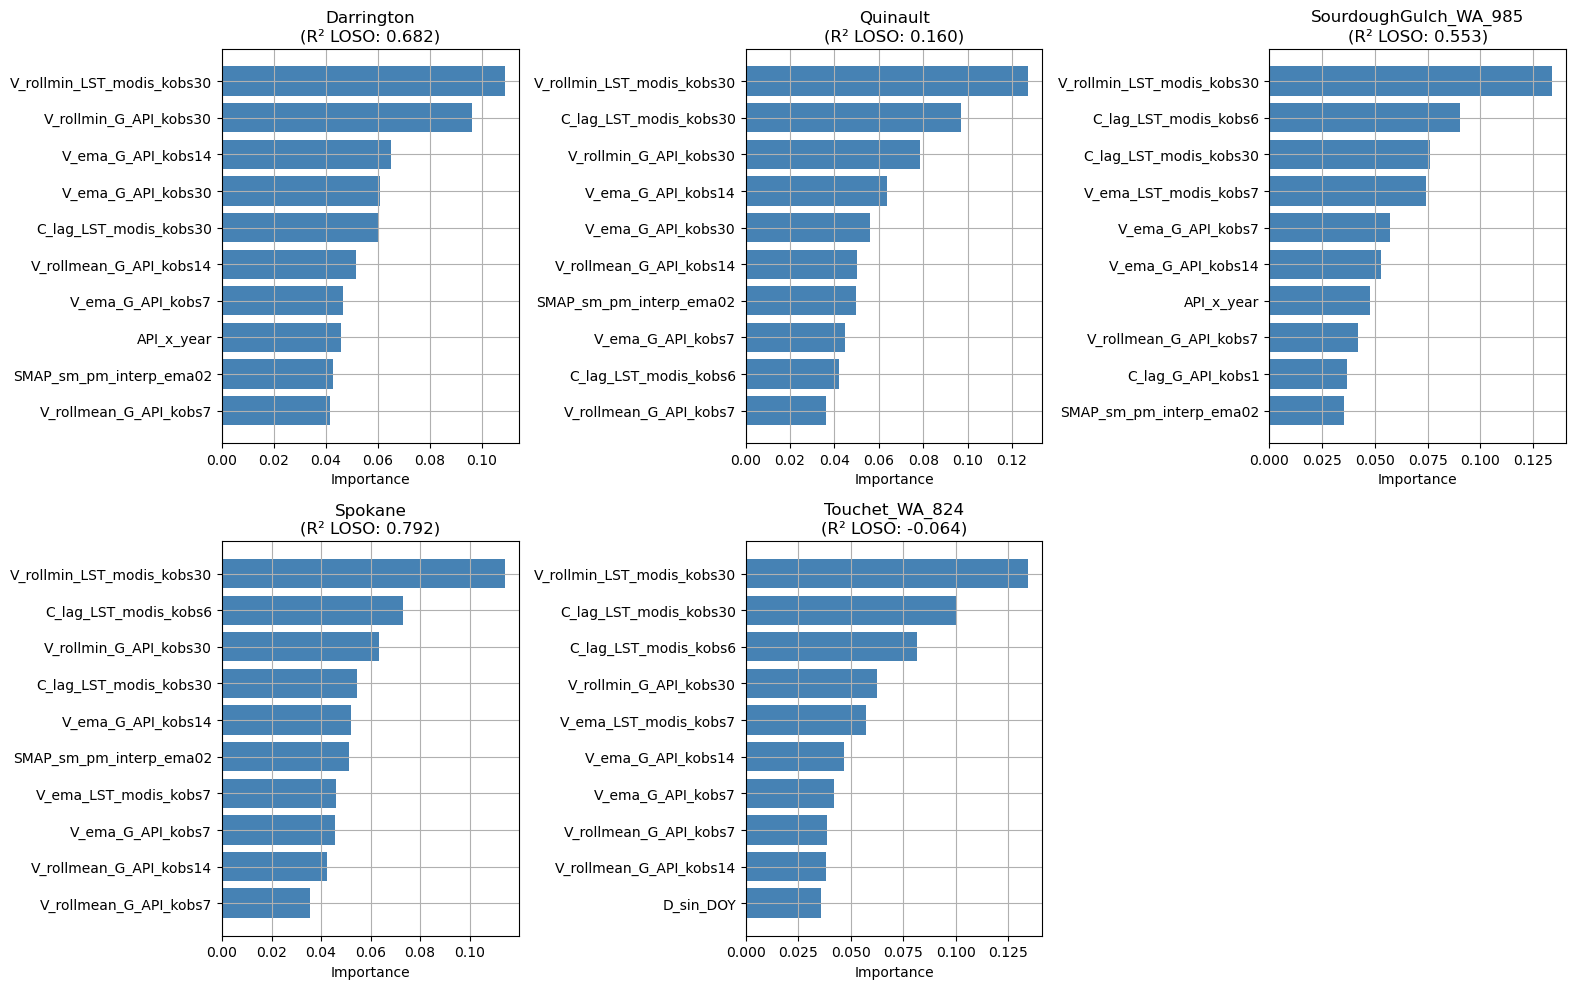

Top 3 features per station:
  Darrington: V_rollmin_LST_modis_kobs30, V_rollmin_G_API_kobs30, V_ema_G_API_kobs14
  Quinault: V_rollmin_LST_modis_kobs30, C_lag_LST_modis_kobs30, V_rollmin_G_API_kobs30
  SourdoughGulch_WA_985: V_rollmin_LST_modis_kobs30, C_lag_LST_modis_kobs6, C_lag_LST_modis_kobs30
  Spokane: V_rollmin_LST_modis_kobs30, C_lag_LST_modis_kobs6, V_rollmin_G_API_kobs30
  Touchet_WA_824: V_rollmin_LST_modis_kobs30, C_lag_LST_modis_kobs30, C_lag_LST_modis_kobs6


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, station in enumerate(sorted(stations)):
    train_mask = trainval_df_d['station_id'] != station
    X_train = trainval_df_d.loc[train_mask, FEATURE_COLS]
    y_train = trainval_df_d.loc[train_mask, TARGET_COL]

    rf_temp = RandomForestRegressor(**RF_PARAMS)
    rf_temp.fit(X_train, y_train)

    importance = rf_temp.feature_importances_
    top_idx = np.argsort(importance)[-10:]

    axes[idx].barh(np.array(FEATURE_COLS)[top_idx], importance[top_idx], color='steelblue')
    axes[idx].set_title(f'{station}\n(R² LOSO: {loso_df[loso_df["station"]==station]["r2"].values[0]:.3f})')
    axes[idx].set_xlabel('Importance')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

print("Top 3 features per station:")
for station in sorted(stations):
    train_mask = trainval_df_d['station_id'] != station
    X_train = trainval_df_d.loc[train_mask, FEATURE_COLS]
    y_train = trainval_df_d.loc[train_mask, TARGET_COL]
    rf_temp = RandomForestRegressor(**RF_PARAMS)
    rf_temp.fit(X_train, y_train)
    top_3 = np.array(FEATURE_COLS)[np.argsort(rf_temp.feature_importances_)[-3:]]
    print(f"  {station}: {', '.join(top_3[::-1])}")

In [54]:
# How much data is imputed vs observed per station?

print("Feature imputation ratio by station:")
print("(higher = more imputed data = lower signal quality)\n")

imputation_cols = [col for col in trainval_df_d.columns if 'interp' in col]

for station in sorted(stations):
    mask = trainval_df_d['station_id'] == station
    imputed_ratio = trainval_df_d.loc[mask, imputation_cols].mean().mean()
    obs_count = mask.sum()
    print(f"{station:25} | n={obs_count:4} | imputed ratio: {imputed_ratio:.2%}")

Feature imputation ratio by station:
(higher = more imputed data = lower signal quality)

Darrington                | n=2048 | imputed ratio: 29.83%
Quinault                  | n=2160 | imputed ratio: 33.72%
SourdoughGulch_WA_985     | n=2190 | imputed ratio: 13.40%
Spokane                   | n=1793 | imputed ratio: 13.16%
Touchet_WA_824            | n=1397 | imputed ratio: 0.00%


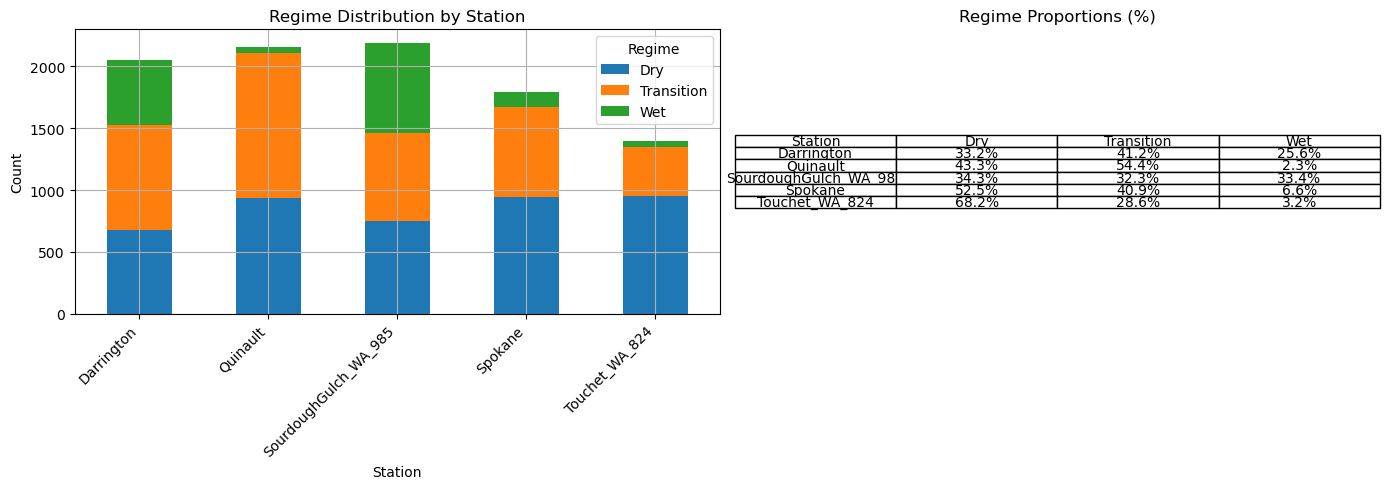


Regime distribution:
 regime                  Dry  Transition   Wet
station_id                                   
Darrington             33.2        41.2  25.6
Quinault               43.3        54.4   2.3
SourdoughGulch_WA_985  34.3        32.3  33.4
Spokane                52.5        40.9   6.6
Touchet_WA_824         68.2        28.6   3.2


In [57]:
def assign_regime(sm):
    if sm < 0.20:
        return 'Dry'
    elif sm < 0.313:
        return 'Transition'
    else:
        return 'Wet'

trainval_df_d['regime'] = trainval_df_d[TARGET_COL].apply(assign_regime)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regime_counts = trainval_df_d.groupby(['station_id', 'regime']).size().unstack(fill_value=0)
regime_counts.plot(kind='bar', stacked=True, ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Regime Distribution by Station')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Station')
axes[0].legend(title='Regime')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

regime_prop = regime_counts.div(regime_counts.sum(axis=1), axis=0) * 100
axes[1].axis('off')

table_data = []
for i in range(len(regime_prop)):
    table_data.append([regime_prop.index[i]] + [f"{regime_prop.iloc[i, j]:.1f}%" for j in range(len(regime_prop.columns))])

table = axes[1].table(cellText=table_data, colLabels=['Station'] + list(regime_prop.columns),
                      cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1].set_title('Regime Proportions (%)')

plt.tight_layout()
plt.show()

print("\nRegime distribution:\n", regime_prop.round(1))

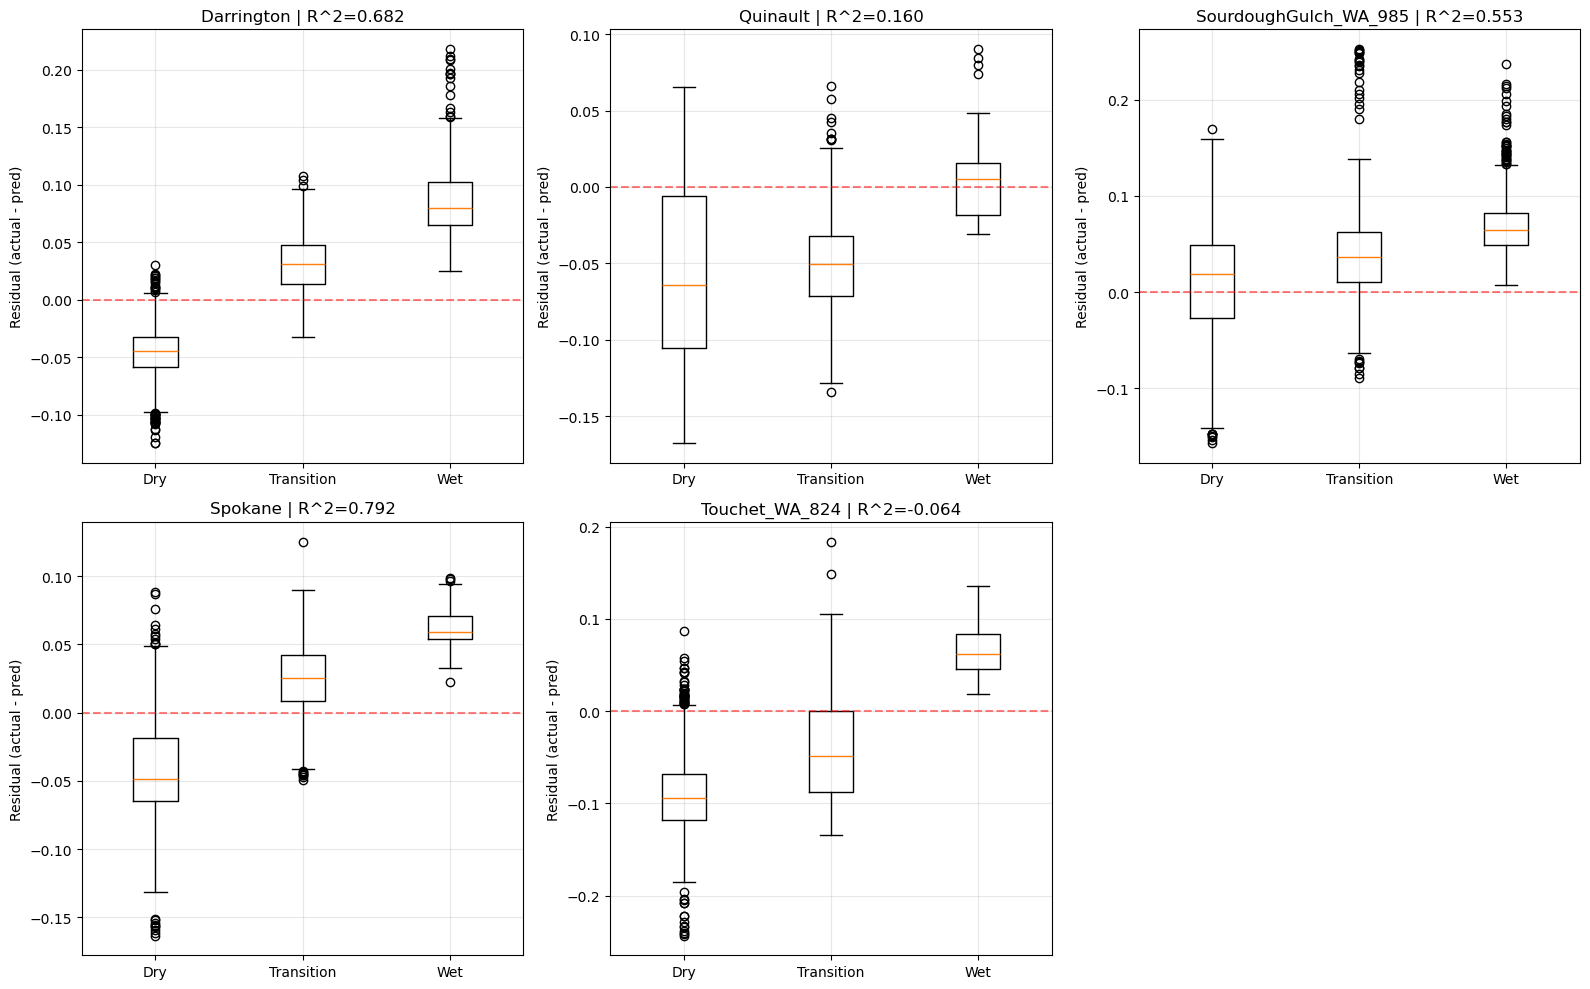


MAE by regime per station:
  Darrington                | Dry          (n= 679): MAE=0.0473
  Darrington                | Transition   (n= 844): MAE=0.0336
  Darrington                | Wet          (n= 525): MAE=0.0858
  Quinault                  | Dry          (n= 936): MAE=0.0651
  Quinault                  | Transition   (n=1174): MAE=0.0530
  Quinault                  | Wet          (n=  50): MAE=0.0236
  SourdoughGulch_WA_985     | Dry          (n= 752): MAE=0.0513
  SourdoughGulch_WA_985     | Transition   (n= 707): MAE=0.0472
  SourdoughGulch_WA_985     | Wet          (n= 731): MAE=0.0688
  Spokane                   | Dry          (n= 942): MAE=0.0484
  Spokane                   | Transition   (n= 733): MAE=0.0300
  Spokane                   | Wet          (n= 118): MAE=0.0632
  Touchet_WA_824            | Dry          (n= 953): MAE=0.0932
  Touchet_WA_824            | Transition   (n= 399): MAE=0.0579
  Touchet_WA_824            | Wet          (n=  45): MAE=0.0640


In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, station in enumerate(sorted(stations)):
    train_mask = trainval_df_d['station_id'] != station
    test_mask = trainval_df_d['station_id'] == station

    X_train = trainval_df_d.loc[train_mask, FEATURE_COLS]
    y_train = trainval_df_d.loc[train_mask, TARGET_COL]
    X_test = trainval_df_d.loc[test_mask, FEATURE_COLS]
    y_test = trainval_df_d.loc[test_mask, TARGET_COL]

    rf_temp = RandomForestRegressor(**RF_PARAMS)
    rf_temp.fit(X_train, y_train)
    y_pred = rf_temp.predict(X_test)

    residuals = y_test.values - y_pred
    regime_test = trainval_df_d.loc[test_mask, 'regime'].values

    regime_residuals = [residuals[regime_test == r] for r in ['Dry', 'Transition', 'Wet']]
    axes[idx].boxplot(regime_residuals, labels=['Dry', 'Transition', 'Wet'])
    axes[idx].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[idx].set_title(f'{station} | R^2={loso_df[loso_df["station"]==station]["r2"].values[0]:.3f}')
    axes[idx].set_ylabel('Residual (actual - pred)')
    axes[idx].grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

print("\nMAE by regime per station:")
for station in sorted(stations):
    test_mask = trainval_df_d['station_id'] == station
    y_test = trainval_df_d.loc[test_mask, TARGET_COL].values
    regime_test = trainval_df_d.loc[test_mask, 'regime'].values

    train_mask = trainval_df_d['station_id'] != station
    X_train = trainval_df_d.loc[train_mask, FEATURE_COLS]
    y_train = trainval_df_d.loc[train_mask, TARGET_COL]
    X_test = trainval_df_d.loc[test_mask, FEATURE_COLS]

    rf_temp = RandomForestRegressor(**RF_PARAMS)
    rf_temp.fit(X_train, y_train)
    y_pred = rf_temp.predict(X_test)

    for regime in ['Dry', 'Transition', 'Wet']:
        mask = regime_test == regime
        if mask.sum() > 0:
            mae_regime = np.abs(y_test[mask] - y_pred[mask]).mean()
            n_regime = mask.sum()
            print(f"  {station:25} | {regime:12} (n={n_regime:4}): MAE={mae_regime:.4f}")

---

_Jakob Balkovec_